# NCF 


In [1]:
%pip install recommenders -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install tensorflow-macos tensorflow-metal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.0/227.0 MB 2.0 MB/s  0:01:39m0:00:0100:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 2.2 MB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 2.3 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 1.2 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 1.4 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 1.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 2.3 MB/s  0:00:11 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 3.0 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: numpy━━━━━━━━━━━━━━━━━━━━━━━━━━━━  8/27 [protobuf]
    Found existing installation: numpy 2.3.5━━━━━━━━━━━━━━━━━━  8/27 [protobuf]
    Uninstalling numpy-2.3.5:━━━━━━━━━━━━━━━━━━━━━━━━━━━━  8/27 [pro

In [2]:
%pip install tf_slim

Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from recommenders.models.ncf.ncf_singlenode import NCF
from recommenders.models.ncf.dataset import Dataset as NCFDataset
from recommenders.evaluation.python_evaluation import (
    precision_at_k, recall_at_k, ndcg_at_k, map_at_k
)
from recommenders.utils.constants import (
    DEFAULT_USER_COL, DEFAULT_ITEM_COL,
    DEFAULT_RATING_COL, DEFAULT_TIMESTAMP_COL
)

sns.set_style('whitegrid')
np.random.seed(42)

print(f"User col:   '{DEFAULT_USER_COL}'")
print(f"Item col:   '{DEFAULT_ITEM_COL}'")
print(f"Rating col: '{DEFAULT_RATING_COL}'")

User col:   'userID'
Item col:   'itemID'
Rating col: 'rating'


In [15]:
df = pd.read_csv('../../data/children_products/clildren_product_cleaned.csv')
print(f"Исходный датасет: {df.shape}")

df_filtered = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
df_filtered = df_filtered.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df_filtered['Дата'] = pd.to_datetime(df_filtered['Дата'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Дата'])

MIN_INTERACTIONS = 5
for _ in range(5):
    user_counts = df_filtered.groupby('Телефон_new').size()
    item_counts = df_filtered.groupby('ID_SKU').size()
    active_users = user_counts[user_counts >= MIN_INTERACTIONS].index
    active_items = item_counts[item_counts >= MIN_INTERACTIONS].index
    before = len(df_filtered)
    df_filtered = df_filtered[
        df_filtered['Телефон_new'].isin(active_users) &
        df_filtered['ID_SKU'].isin(active_items)
    ]
    if len(df_filtered) == before:
        break

print(f"Пользователей: {df_filtered['Телефон_new'].nunique():,}")
print(f"Товаров:       {df_filtered['ID_SKU'].nunique():,}")
print(f"Взаимодействий:{len(df_filtered):,}")

Исходный датасет: (610913, 16)
Пользователей: 17,442
Товаров:       8,488
Взаимодействий:227,170


In [16]:
# Microsoft Recommenders ожидает колонки: userID, itemID, rating
interactions = (
    df_filtered
    .groupby(['Телефон_new', 'ID_SKU'])
    .agg(timestamp=('Дата', 'max'))
    .reset_index()
)
interactions[DEFAULT_RATING_COL] = 1.0  # бинарный: факт покупки
interactions.rename(columns={
    'Телефон_new': DEFAULT_USER_COL,
    'ID_SKU':      DEFAULT_ITEM_COL,
    'timestamp':   DEFAULT_TIMESTAMP_COL
}, inplace=True)

# Сплит по дате (80/20) — как в asl.ipynb
interactions = interactions.sort_values(DEFAULT_TIMESTAMP_COL)
split_ts = interactions[DEFAULT_TIMESTAMP_COL].quantile(0.8)
print(f"Дата разделения: {split_ts}")

train_df = interactions[interactions[DEFAULT_TIMESTAMP_COL] <  split_ts].copy()
test_df  = interactions[interactions[DEFAULT_TIMESTAMP_COL] >= split_ts].copy()

# Оставляем в тесте только пользователей из трейна
train_users = set(train_df[DEFAULT_USER_COL].unique())
test_df = test_df[test_df[DEFAULT_USER_COL].isin(train_users)]

print(f"Train: {len(train_df):,} пар, {train_df[DEFAULT_USER_COL].nunique():,} users")
print(f"Test:  {len(test_df):,} пар,  {test_df[DEFAULT_USER_COL].nunique():,} users")

Дата разделения: 2017-04-18 23:48:00
Train: 162,552 пар, 15,609 users
Test:  24,193 пар,  3,824 users


In [ ]:
import tempfile, os

user2id = {u: i for i, u in enumerate(interactions[DEFAULT_USER_COL].unique())}
item2id = {it: i for i, it in enumerate(interactions[DEFAULT_ITEM_COL].unique())}

def encode(df):
    d = df.copy()
    d[DEFAULT_USER_COL] = d[DEFAULT_USER_COL].map(user2id)
    d[DEFAULT_ITEM_COL] = d[DEFAULT_ITEM_COL].map(item2id)
    return d

train_enc = encode(train_df).sort_values(DEFAULT_USER_COL)
test_enc  = encode(test_df).sort_values(DEFAULT_USER_COL)

tmp_dir    = tempfile.mkdtemp()
train_file = os.path.join(tmp_dir, 'train.csv')
test_file  = os.path.join(tmp_dir, 'test.csv')

train_enc[[DEFAULT_USER_COL, DEFAULT_ITEM_COL, DEFAULT_RATING_COL]].to_csv(train_file, index=False)
test_enc[[DEFAULT_USER_COL, DEFAULT_ITEM_COL, DEFAULT_RATING_COL]].to_csv(test_file,  index=False)

data = NCFDataset(
    train_file=train_file,
    test_file=test_file,
    seed=42,
    n_neg=4,
    n_neg_test=99,
    col_user=DEFAULT_USER_COL,
    col_item=DEFAULT_ITEM_COL,
    col_rating=DEFAULT_RATING_COL,
)

print(f"Пользователей: {data.n_users:,}")
print(f"Товаров:       {data.n_items:,}")

INFO:recommenders.models.ncf.dataset:Indexing /var/folders/2s/l9p15g5j1t3gkzyssvhh423r0000gn/T/tmp4gj5m5mb/train.csv ...
INFO:recommenders.models.ncf.dataset:Indexing /var/folders/2s/l9p15g5j1t3gkzyssvhh423r0000gn/T/tmp4gj5m5mb/test.csv ...
INFO:recommenders.models.ncf.dataset:Creating full leave-one-out test file /var/folders/2s/l9p15g5j1t3gkzyssvhh423r0000gn/T/tmp4gj5m5mb/test_full.csv ...
100%|██████████| 3824/3824 [00:11<00:00, 339.41it/s]
INFO:recommenders.models.ncf.dataset:Indexing /var/folders/2s/l9p15g5j1t3gkzyssvhh423r0000gn/T/tmp4gj5m5mb/test_full.csv ...


Пользователей: 15,609
Товаров:       8,410


In [18]:
model = NCF(
    n_users=data.n_users,
    n_items=data.n_items,
    model_type='NeuMF',
    n_factors=64,             # размерность эмбеддингов
    layer_sizes=[256, 128, 64], # MLP слои
    n_epochs=20,
    batch_size=1024,
    learning_rate=1e-3,
    verbose=2,               # вывод каждые 2 эпохи
    seed=42,
)

model.fit(data)

2026-03-24 19:28:17.826399: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-03-24 19:28:17.826432: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-03-24 19:28:17.826440: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 13.50 GB
2026-03-24 19:28:17.826473: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-24 19:28:17.826483: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-03-24 19:28:17.832992: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-03-24 19:28:17.837529: I tensorflow/core/gr

In [23]:
known_users = set(model.user2id.keys())
known_items = sorted(model.item2id.keys())  # все известные товары

test_users_eval = [u for u in test_enc[DEFAULT_USER_COL].unique() if u in known_users]

all_predictions = []
for user in test_users_eval:
    # Скорим все известные товары (как ALS) — честное полное ранжирование
    scores = model.predict(
        [user] * len(known_items),
        known_items,
        is_list=True
    )
    for item, score in zip(known_items, scores):
        all_predictions.append({
            DEFAULT_USER_COL:   user,
            DEFAULT_ITEM_COL:   item,
            DEFAULT_RATING_COL: score
        })

predictions_df = pd.DataFrame(all_predictions)
print(f"Предсказаний: {len(predictions_df):,}")
print(predictions_df.head())

Предсказаний: 32,159,840
   userID  itemID  rating
0       7       0     0.0
1       7       1     0.0
2       7       2     0.0
3       7       3     0.0
4       7       4     0.0


In [ ]:
test_enc_eval = test_enc[
    test_enc[DEFAULT_USER_COL].isin(known_users) &
    test_enc[DEFAULT_ITEM_COL].isin(known_items)
]

results = {}
for k in [5, 10, 20]:
    results[k] = {
        'precision': precision_at_k(test_enc_eval, predictions_df, k=k,
                                    col_user=DEFAULT_USER_COL,
                                    col_item=DEFAULT_ITEM_COL,
                                    col_rating=DEFAULT_RATING_COL,
                                    col_prediction=DEFAULT_RATING_COL),
        'recall':    recall_at_k(test_enc_eval, predictions_df, k=k,
                                 col_user=DEFAULT_USER_COL,
                                 col_item=DEFAULT_ITEM_COL,
                                 col_rating=DEFAULT_RATING_COL,
                                 col_prediction=DEFAULT_RATING_COL),
        'ndcg':      ndcg_at_k(test_enc_eval, predictions_df, k=k,
                               col_user=DEFAULT_USER_COL,
                               col_item=DEFAULT_ITEM_COL,
                               col_rating=DEFAULT_RATING_COL,
                               col_prediction=DEFAULT_RATING_COL),
        'map':       map_at_k(test_enc_eval, predictions_df, k=k,
                              col_user=DEFAULT_USER_COL,
                              col_item=DEFAULT_ITEM_COL,
                              col_rating=DEFAULT_RATING_COL,
                              col_prediction=DEFAULT_RATING_COL),
    }

for k in [5, 10, 20]:
    r = results[k]
    print(f"\nK={k}:")
    print(f"  Precision@{k}: {r['precision']:.4f}")
    print(f"  Recall@{k}:    {r['recall']:.4f}")
    print(f"  MAP@{k}:       {r['map']:.4f}")
    print(f"  NDCG@{k}:      {r['ndcg']:.4f}")

=== NCF (Microsoft Recommenders NeuMF) ===

K=5:
  Precision@5: 0.0188
  Recall@5:    0.0089
  MAP@5:       0.0123
  NDCG@5:      0.0200

K=10:
  Precision@10: 0.0180
  Recall@10:    0.0190
  MAP@10:       0.0104
  NDCG@10:      0.0217

K=20:
  Precision@20: 0.0166
  Recall@20:    0.0505
  MAP@20:       0.0111
  NDCG@20:      0.0306


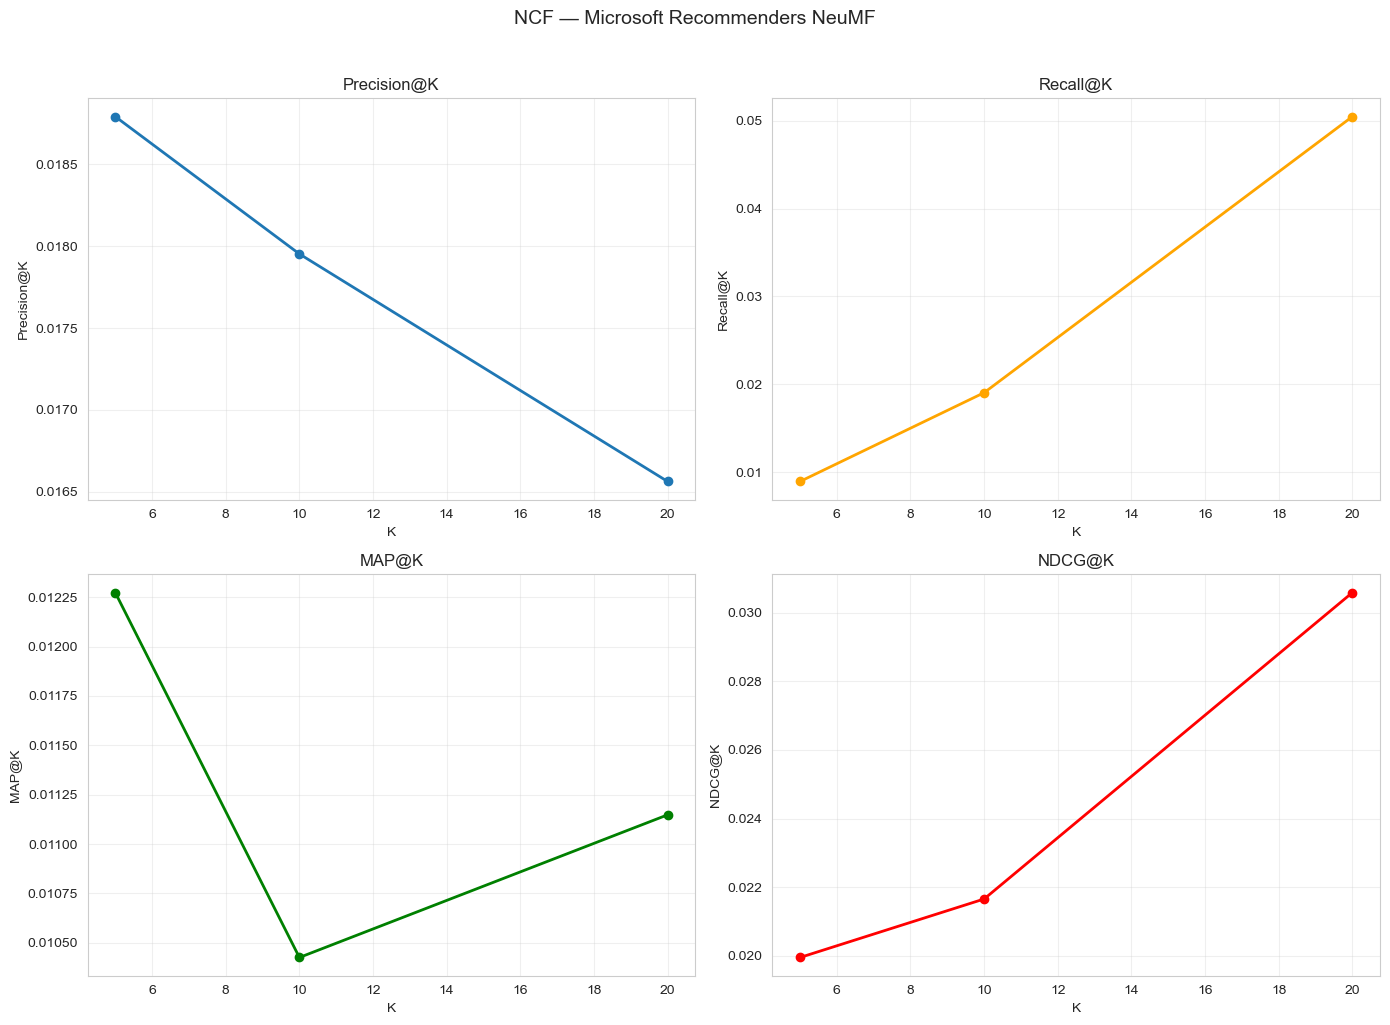

In [25]:
metrics_df = pd.DataFrame(results).T
metrics_df.index.name = 'K'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(metrics_df.index, metrics_df['precision'], marker='o', linewidth=2)
axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Precision@K')
axes[0, 0].set_title('Precision@K'); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(metrics_df.index, metrics_df['recall'], marker='o', linewidth=2, color='orange')
axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Recall@K')
axes[0, 1].set_title('Recall@K'); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(metrics_df.index, metrics_df['map'], marker='o', linewidth=2, color='green')
axes[1, 0].set_xlabel('K'); axes[1, 0].set_ylabel('MAP@K')
axes[1, 0].set_title('MAP@K'); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(metrics_df.index, metrics_df['ndcg'], marker='o', linewidth=2, color='red')
axes[1, 1].set_xlabel('K'); axes[1, 1].set_ylabel('NDCG@K')
axes[1, 1].set_title('NDCG@K'); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('NCF — Microsoft Recommenders NeuMF', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()